#CONFIGURATION 3


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CHANGE "/content/drive" to data repositiory "DATA"

Multiple arms[link text](https://)

#(FAIR-CMAB-delayed)

In [ ]:
import numpy as np
import pandas as pd

class FairLearn:
    def __init__(self, N, K, ri, alpha, learn_func,mu,T):
        self.K = K
        self.N = N
        self.mu = mu
        self.ri = np.array(ri)
        self.alpha = alpha
        self.learn_func = learn_func
        # self.n = n
        self.S = np.zeros(N)
        # self.n=np.array(n)
        # self.count =count
    def bernoulli_reward(self,p):
        return np.random.binomial(1, p)

    def Learn_UCB(self,learner_pulls, estimated_means, N, K, ucb_values, t_l):
        # Update UCB values for each arm
        for i in range(N):
            if learner_pulls[i] > 0:
                ucb_values[i] = estimated_means[i] + np.sqrt(3* np.log(t_l) / 2*learner_pulls[i])
            else:
                ucb_values[i] =1  # Initialize UCB to infinity if arm has not been pulled yet
        selected_arms = np.argsort(ucb_values)[-K:]
        best_k_mu=np.argsort(mu)[-K:]
        regret = 0
        total_reward = 0
        # print("learner_pulls:",learner_pulls)
        # print("estimated_means:",estimated_means)
        # print("ucb_values:",ucb_values)
        # print("selected arm:",selected_arms)
        for arm in selected_arms:
            # print(mu)
            reward = self.bernoulli_reward(mu[arm])  # Generate reward based on Bernoulli distribution
            learner_pulls[arm] += 1
            estimated_means[arm] = ((learner_pulls[arm] - 1) * estimated_means[arm] + reward) / learner_pulls[arm]  # Update empirical mean
            estimated_means[arm] = min(1, estimated_means[arm])
            total_reward += reward
        # total_reward=total_reward/K
        regret += np.sum(best_k_mu) - total_reward # Regret calculation


        return regret, learner_pulls, estimated_means, total_reward
    ##############################
    def pull_arm(self,T,count):
################################################3
        learner_pulls = np.zeros(N)  # How many times each arm has been pulled
        estimated_means = np.zeros(N)  # Empirical mean rewards for each arm
        ucb_values = np.zeros(N)  # UCB values for each arm
        t_l = 1  # Start time

        total_regret = 0
        total_rewards = 0

        learner_t=[]
        learner_act_t=[]
        cumm_regret=[]

        Fair_pull_list=[]
        Fair_time_list=[]
##################################################
        """
        Run the algorithm for one time step.
        """
        n=np.zeros(self.N,dtype=int)
        Fair_pull_list.append(list(n))
        t=1
        # t = (np.sum(self.n))/K  +1  # Time step
        # n=np.zeros(N)
        while t<T:
          # print("t",t)
          # print("OK",n)
          # Calculate fairness constraint for each arm
          values = [(i, self.ri[i] * (t - 1) - n[i]) for i in range(self.N)]
          # print("values, t", values, t)
          for i, value in values:
            if value > 1:
                raise ValueError(f"Error: Value at index {i} is greater than 1. Value: {value}")
          # print(values)
          # Filter arms that satisfy the condition: value > self.alpha
          filtered_arms = [(i, val) for i, val in values if val > self.alpha]
          # Sort by the values in descending order to get the top K
          top_K_arms = sorted(filtered_arms, key=lambda x: x[1], reverse=True)[:K]
          # Extract only the arm indices from the top K
          A_t = [i for i, val in top_K_arms]
          # for i in A_t:
          #   if i
          # print("action time t,A_t",t, A_t)
          reward=0
          # print("A",n)
          if A_t:
              filtered_arms = [(i, val) for i, val in values ]
          # Sort by the values in descending order to get the top K
              top_K_arms = sorted(filtered_arms, key=lambda x: x[1], reverse=True)[:K]
              # Extract only the arm indices from the top K
              A_t = [i for i, val in top_K_arms]
              # Pull arm with highest fairness value
              # i_t = max(A_t, key=lambda i: self.ri[i] * (t - 1) - self.N[i])
              # print("#########A_t not empty##########", A_t, mu[A_t],)
                # Simulate pulling arm
              for i_t in A_t:
                # print("It",i_t, mu[i_t])
                # reward += self.pull_arm_i(mu[i_t])
                n[i_t] =n[i_t]+1
                # print("one",n[i_t],n)
                # self.S[i_t] += reward
              # mean_r= reward/K
              count+=1

              Fair_time_list.append(t)
              Fair_pull_list.append(list(n))

              # Important to print
              # print("fair count",count,n)
          else:
              # Otherwise, use the learning algorithm
              # print("Learn")
              ##########################################################################3
              regret, learner_pulls, estimated_means, total_reward = self.Learn_UCB(learner_pulls, estimated_means, N, K, ucb_values, t_l)
              total_regret += regret/t_l
              total_rewards += total_reward
              learner_t.append(t)
              learner_act_t.append(t_l)
              cumm_regret.append(total_regret)
              t_l += 1
              self.learn_func(self.N, self.S)
              # Learn_time_list
              # cummulative regret
          t=t+1
        return n,count,cumm_regret, learner_t, learner_act_t,Fair_pull_list , Fair_time_list
    def pull_arm_i(self, prob):
        return self.bernoulli_reward(prob)    # Random reward (0 or 1)

def learn(N, S):
        # print(f"Learning from pulls: N={N}, S={S}")
        pass
# ######################################################################################

def generate_random_array(a,b,N):
    # Generate random numbers
    v = np.random.uniform(a,b, N)
    return v
N=20
K=5
kappa=N/K
eps=.01


patil_fair_pull_list=[]
patil_regret_list=[]
patil_fv_list=[]
Time_list=[]

dataframes1=[]
dataframes2=[]
dataframes3=[]
for i in range(100):
    T = 100000
    r=generate_random_array(0.001,1/kappa-eps,N)
    mu=generate_random_array(0.5,1,N)


        # print(r)
        # print("to ensure",r,r*T)
    alpha=0
    count=0
    n=np.zeros(N,dtype=int)
    # Create Fair-Learn instance

    fair_learn = FairLearn(N,K, r, alpha, learn,mu,T)
    # print("hi")
    # Simulate pulling arms over multiple rounds
    count,n,total_regret1, t_1, t_l_1,Fair_pull_list1 , Fair_time_list1=fair_learn.pull_arm(T,count)
        # print("fair count, n",count,n,r*T )


    import matplotlib.pyplot as plt
    time=[]
    for i in range(1,T):
      time.append(i)
    lookup_dict = dict(zip(t_1, total_regret1))
    output_list = []
    last_value = 0  # Initialize last_value with 0 or any starting value

    for elem in time:
        if elem in lookup_dict:
            last_value = lookup_dict[elem]  # Update last_value if elem is in the lookup dictionary
        output_list.append(last_value)

    patil_regret_list.append(output_list)




    lookup_dict2 = dict(zip(Fair_time_list1, Fair_time_list1))

    output_list2 = []
    last_value2 = 0  # Initialize last_value with 0 or any starting value

    for elem2 in time:
        if elem2 in lookup_dict2:
            last_value2 += 1  # Update last_value if elem is in the lookup dictionary
        output_list2.append(last_value2)



    FPL=np.array(Fair_pull_list1)
    r1=np.array(r)
    out =[]

    t=1

    for index in output_list2:

        # if(t==1):
        #   # print(r1 * (t-1) ,FPL[index],output_list2[0])
        diff = r1 * (t-1) - FPL[index]  # Calculate r*(t-1) - n[t-1]
        out.append(np.max(diff))  # Find the index of the maximum difference
        t+=1

    patil_fv_list.append(out)



    df_name = f'df_{i}'  # Dynamic name
    df = pd.DataFrame({df_name: output_list})
    dataframes1.append(df)
    combined_df1 = pd.concat(dataframes1, ignore_index=True,axis=1)
    combined_df1.to_csv('/content/drive/MyDrive/AAMAS2025_5/data1.csv', index=False)

    mean_df1 = combined_df1.mean(axis=1)
    std_df1 = combined_df1.std(axis=1)

    df_name = f'df2_{i}'  # Dynamic name
    df = pd.DataFrame({df_name: output_list2})
    dataframes2.append(df)
    combined_df2 = pd.concat(dataframes2, ignore_index=True,axis=1)
    combined_df2.to_csv('/content/drive/MyDrive/AAMAS2025_5/data2.csv', index=False)
    mean_df2 = combined_df2.mean(axis=1)
    std_df2 = combined_df2.std(axis=1)

    df_name = f'df3_{i}'  # Dynamic name
    df = pd.DataFrame({df_name: out})
    dataframes3.append(df)
    combined_df3 = pd.concat(dataframes3, ignore_index=True,axis=1)
    combined_df3.to_csv('/content/drive/MyDrive/AAMAS2025_5/data3.csv', index=False)
    mean_df3 = combined_df3.mean(axis=1)
    std_df3 = combined_df3.std(axis=1)





In [ ]:
mean_df1.to_csv('/content/drive/MyDrive/AAMAS2025_5/data4.csv', index=False)
std_df1.to_csv('/content/drive/MyDrive/AAMAS2025_5/data5.csv', index=False)
mean_df2.to_csv('/content/drive/MyDrive/AAMAS2025_5/data6.csv', index=False)
std_df2.to_csv('/content/drive/MyDrive/AAMAS2025_5/data7.csv', index=False)
mean_df3.to_csv('/content/drive/MyDrive/AAMAS2025_5/data8.csv', index=False)
std_df3.to_csv('/content/drive/MyDrive/AAMAS2025_5/data9.csv', index=False)

In [ ]:
plt.figure(figsize=(10, 6))
# plt.plot(time, mean_df1.to_numpy(), label='Patil et.al.', color='green')


x_values = range(len(mean_df1))
mean_values=mean_df1
std_values= std_df1
# Plot the mean line
plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)

# Shade the area within 1 standard deviation of the mean (no label for this shading)
plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='green', alpha=0.2)


plt.xlabel('Total Time (T)',fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Average Regret',fontsize=14, fontweight='bold')
plt.title('Cumulative Average Regret vs Time',fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=12, prop={'weight':'bold'},loc='upper left')
plt.grid(True)
plt.show()


x_values = range(len(mean_df2))
mean_values=mean_df2
std_values= std_df2

plt.figure(figsize=(10, 6))
plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)
# Shade the area within 1 standard deviation of the mean (no label for this shading)
plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='green', alpha=0.2)
# plt.plot(time, mean_df2.to_numpy(), label='Patil et.al.', color='green')
plt.xlabel(rf'Time Horizon (T)',fontsize=14, fontweight='bold')
plt.ylabel('Fairness Pulls',fontsize=14, fontweight='bold')
plt.title('Fairness Pulls vs Time ',fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=12, prop={'weight':'bold'},loc='upper left')
plt.grid(True)
plt.show()

x_values = range(len(mean_df3))
mean_values=mean_df3
std_values= std_df3

plt.figure(figsize=(10, 6))
plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)
# Shade the area within 1 standard deviation of the mean (no label for this shading)
plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='green', alpha=0.2)
# plt.plot(time, mean_df3.to_numpy(), label='Patil et.al.', color='green')
plt.xlabel('Time Horizon (T)',fontsize=14, fontweight='bold')
plt.ylabel('Fairness Violation',fontsize=14, fontweight='bold')
plt.title('Fairness Violation vs Time',fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=12, prop={'weight':'bold'},loc='upper right')
plt.grid(True)
plt.show()


#FAIR-CMAB

In [ ]:
import numpy as np
import pandas as pd


############  UCB  ###################

def bernoulli_reward(p):
    return np.random.binomial(1, p)

def Learn_UCB(learner_pulls, estimated_means, N, K, ucb_values, t_f,mu):
    # Update UCB values for each arm
    for i in range(N):
        if learner_pulls[i] > 0:
            ucb_values[i] = estimated_means[i] + np.sqrt(3* np.log(t_f) / 2*learner_pulls[i])
        else:
            ucb_values[i] =1  # Initialize UCB to infinity if arm has not been pulled yet
    selected_arms = np.argsort(ucb_values)[-K:]
    best_k_mu=np.argsort(mu)[-K:]
    regret = 0
    total_reward = 0

    for arm in selected_arms:
        reward = bernoulli_reward(mu[arm])  # Generate reward based on Bernoulli distribution
        learner_pulls[arm] += 1
        estimated_means[arm] = ((learner_pulls[arm] - 1) * estimated_means[arm] + reward) / learner_pulls[arm]  # Update empirical mean
        estimated_means[arm] = min(1, estimated_means[arm])
        total_reward += reward
    # total_reward=total_reward/K
    regret += np.sum(best_k_mu) - total_reward # Regret calculation


    return regret, learner_pulls, estimated_means, total_reward
##############################

def compute_eta_H(fairness_vector, K, H):
    # Step 1: Compute ceil(r_i * H) for each element in fairness_vector
    # ceil_ri_H = np.ceil(np.array(fairness_vector) * H)
    ceil_ri_H = (np.array(fairness_vector))
    # Step 2: Compute the first term of the max: ceil(sum(ceil(r_i * H)) / K)
    sum_ceil_ri_H = np.sum(ceil_ri_H)
    first_term = np.ceil(sum_ceil_ri_H / K)
    # Step 3: Compute the second term of the max: max(ceil(r_i * H))
    second_term = np.max(ceil_ri_H)
    # Step 4: Compute eta_H
    eta_H = (1 / H) * max(first_term, second_term)
    return eta_H

# LRPT Algorithm
def LRPT(p, l, T, K,H, n_pulls,t,Fair_pull_list,Fair_time):
    # print("###########3r################",r)
    # Initialize processing counters for each arm
    n = np.zeros(N)
    pulls = np.zeros(N)
    t_f_loop = 1
    eta_H = compute_eta_H(p, K, H)
    # print("#######################################")
    # print("LRPT")
    # print("etaH",eta_H, l)

    while t_f_loop <= l and t <= T:
        # Fair_pull_list.append(t)


        t+=1

        values = [(i, r[i] * (t - 1) - n_pulls[i]) for i in range(len(p))]
        # print("values-- pulls",values,n_pulls,t)
        arm_values = p - n
        selected_arms = np.argsort(arm_values)[-K:]  # Top K arms
        count =0
        for arm in range(p.size):
          if arm_values[arm]<0 :
            count+=1
          # else:
          #   pass
        ###################Important
        # if count==p.size:
        #   print("Hi",count)

          # break
         ###################Important
        # for i, value in values:
        #   if value > 1:
        #       print("error")
        #       print(values,t)
        for arm in selected_arms:
            n[arm] += 1
            n_pulls[arm]+=1
        t_f_loop += 1
        Fair_pull_list.append(list(n_pulls))
        Fair_time.append(t)
    pulls=n


    E = np.where((p - n) < 0)[0]
    # print("PPPPPPPPNNNNNNNNNEEEEE",p,n, E)
    return pulls,n_pulls,E,t,Fair_pull_list,Fair_time


# Fair CMAB Framework (r-CMAB-F)
def fair_CMAB_framework(r, H, N, K, T,mu):
    ###############UCB###################################################33

    learner_pulls = np.zeros(N)  # How many times each arm has been pulled
    estimated_means = np.zeros(N)  # Empirical mean rewards for each arm
    ucb_values = np.zeros(N)  # UCB values for each arm
    t_l = 1  # Start time
    total_regret = 0
    total_rewards = 0
    learner_t=[]
    learner_act_t=[]
    cumm_regret=[]
    Fair_pull_list=[]
    Fair_time_list=[]
    ##################################################################3
    t=0
    pulls = np.zeros(N)
    n_pulls = np.zeros(N)

    eta_H = compute_eta_H(np.ceil(r*H), K, H)  # Placeholder, compute based on your specific problem
    old= eta_H
    # print(f"Computed eta_H imp: {eta_H}")
    l = int(eta_H*H)
    p = np.zeros(N)
    # Initialize the first round of LRPT
    r_ceil_H = np.ceil(r * H).astype(int)

    pulls,n_pulls,E,t_1,Fair_pull_list, Fair_time_list=LRPT(r_ceil_H, l, T, K,H,n_pulls,t,Fair_pull_list,Fair_time_list)

    # n_pulls+=pulls,n_pulls
    # print("pulls",pulls,n_pulls)
    # print("True t",t_1)
    t = np.ceil(H * eta_H)
    # same as t1
    # print("True t",t_1,t)
    j = 2
    count=0
    count+=l
    while t <= T:
        # Compute L and U sets
        L = [i for i in range(N) if np.ceil(r[i] * j * H) < np.ceil(r[i] * (j - 1) * H) + np.ceil(r[i] * H)]
        U = [i for i in range(N) if np.ceil(r[i] * j * H) == np.ceil(r[i] * (j - 1) * H) + np.ceil(r[i] * H)]
        # Assign p values based on L and U sets
        p[L] = np.floor(r[L] * H)
        p[U] = np.ceil(r[U] * H)
        p[E] -= 1
        # Compute new l and run LRPT
        eta_j_H= compute_eta_H(np.ceil(r * (j ) * H), K, j*H)
        eta_j_1H = old
        l = np.ceil(j * H *eta_j_H - (j - 1) * H * eta_j_1H)
        #For next round eta_JH eta_J-1H will be old eta_jh
        old = eta_j_H
        ###################
        pulls,n_pulls, E,t_1,Fair_pull_list,Fair_time_list= LRPT(p, l, T, K, H,n_pulls,t,Fair_pull_list,Fair_time_list)

        # Update time and run learning process
        t += l
        # same as t1
        # print("True t",t_1,t)
        count+=l
        t_l_loop=0
        while t_l_loop < (H - l)  and t <= T:
            ##########UCB############################################
            regret, learner_pulls, estimated_means, total_reward = Learn_UCB(learner_pulls, estimated_means, N, K, ucb_values, t_l,mu)
            total_regret += regret/t_l
            total_rewards += total_reward
            learner_t.append(t)
            learner_act_t.append(t_l)
            cumm_regret.append(total_regret)
            t_l += 1
            #######################################################################
            t_l_loop+=1
            t += 1

        j += 1
        # print("##################faircalls#COUNT####npulls##### rt#####t######",count,n_pulls,r*t,t)
    # print("###################COUNT####npulls##### rt###########",count,n_pulls,r*T,r)
    return cumm_regret,learner_t,learner_act_t,Fair_pull_list,Fair_time_list

def generate_random_array(a,b,N):
    # Generate random numbers
    v = np.random.uniform(a,b, N)
    return v



N=20
K=5
kappa=N/K
eps=.01




our_fair_pull_list=[]
our_regret_list=[]
our_fv_list=[]

for H in [100,200,500,1000]:
  # print(H)
  dataframes1=[]
  dataframes2=[]
  dataframes3=[]
  for i in range(100):

    r=generate_random_array(0.001,1/kappa-eps,N)
    mu=generate_random_array(0.5,1,N)


    # r=  np.array([0.40, 0.177, 0.133, 0.05])

    T = 100000  # Total time steps
    # if ( H%K==0 and np.sum(r) <K/2 and np.max(r)< 1/(2) ):
    # print("to ensure",r,r*T)
    # fair_CMAB_framework(r, H, N, K, T)
    total_regret, t, t_l,Fair_pull_list , Fair_time_list=fair_CMAB_framework(r, H, N, K, T,mu)

    # import matplotlib.pyplot as plt
    # plt.rcParams['font.size'] = 14  # Overall font size
    # plt.rcParams['mathtext.fontset'] = 'stix'  # Change math font to STIX
    # plt.rcParams['mathtext.default'] = 'regular'  # Use regular math font
    time=[]
    for i in range(1,T):
      time.append(i)

    lookup_dict = dict(zip(t, total_regret))

    output_list = []
    last_value = 0  # Initialize last_value with 0 or any starting value

    for elem in time:
        if elem in lookup_dict:
            last_value = lookup_dict[elem]  # Update last_value if elem is in the lookup dictionary
        output_list.append(last_value)

    our_regret_list.append(output_list)

    # plt.figure(figsize=(10, 6))
    # plt.plot(time, output_list, label='r-CMAB-F', color='blue')
    # plt.xlabel(rf'Total Time ($T$) with $H={H}$',fontsize=14, fontweight='bold')
    # plt.ylabel('Cumulative Regret',fontsize=14, fontweight='bold')
    # plt.title('Cumulative Regret vs Time',fontsize=14, fontweight='bold')
    # plt.xticks(fontsize=12, fontweight='bold')
    # plt.yticks(fontsize=12, fontweight='bold')
    # plt.legend(fontsize=14, prop={'weight':'bold'},loc='upper left')
    # plt.grid(True)
    # plt.show()


    lookup_dict2 = dict(zip(Fair_time_list, Fair_time_list))

    output_list2 = []
    last_value2 = 0  # Initialize last_value with 0 or any starting value

    for elem2 in time:
        if elem2 in lookup_dict2:
            last_value2 += 1  # Update last_value if elem is in the lookup dictionary
        output_list2.append(last_value2)
    our_fair_pull_list.append(output_list2)
    # plt.figure(figsize=(10, 6))
    # plt.plot(time, output_list2, label='r-CMAB-F', color='blue')
    # plt.xlabel(rf'Time Horizon ($T$) with $H={H}$',fontsize=14, fontweight='bold')
    # plt.ylabel('Fairness Pulls',fontsize=14, fontweight='bold')
    # plt.title('Fairness Pulls vs Time',fontsize=14, fontweight='bold')
    # plt.xticks(fontsize=12, fontweight='bold')
    # plt.yticks(fontsize=12, fontweight='bold')
    # plt.legend(fontsize=14, prop={'weight':'bold'},loc='upper left')
    # plt.grid(True)
    # plt.show()




    FPL=np.array(Fair_pull_list)
    r1=np.array(r)
    out =[]

    t=1
    for index in output_list2:
        diff = r1 * (t-1) - FPL[index-1]  # Calculate r*(t-1) - n[t-1]
        out.append(np.max(diff))  # Find the index of the maximum difference
        t+=1
    our_fv_list.append(out)

    # plt.figure(figsize=(10, 6))
    x = range(0, len(time))

# Create y values (a constant list of 1s)
    y = [1] * len(x)


    # plt.plot(x,y, color='orange', linestyle='--', linewidth=2, label=r'$r_i t- n_{i,t}=1$')
    # plt.plot(time, out, label='r-CMAB-F', color='blue')
    # plt.xlabel(rf'Time Horizon (T)',fontsize=14, fontweight='bold')
    # plt.ylabel('Max Fairness Violation',fontsize=14, fontweight='bold')
    # plt.title('Fairness Violation vs Time',fontsize=14, fontweight='bold')
    # plt.xticks(fontsize=12, fontweight='bold')
    # plt.yticks(fontsize=12, fontweight='bold')
    # plt.legend(fontsize=14, prop={'weight':'bold'},loc='upper right')
    # plt.grid(True)
    # plt.show()AAMAS2025_4

    df_name = f'df_{i}_{H}'  # Dynamic name
    df = pd.DataFrame({df_name: output_list})
    dataframes1.append(df)
    combined_df1 = pd.concat(dataframes1, ignore_index=True,axis=1)
    combined_df1.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/data1_{H}.csv', index=False)

    mean_df4 = combined_df1.mean(axis=1)
    std_df4 = combined_df1.std(axis=1)

    df_name = f'df2_{i}_{H}'  # Dynamic name
    df = pd.DataFrame({df_name: output_list2})
    dataframes2.append(df)
    combined_df2 = pd.concat(dataframes2, ignore_index=True,axis=1)
    combined_df2.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/data2_{H}.csv', index=False)
    mean_df5 = combined_df2.mean(axis=1)
    std_df5 = combined_df2.std(axis=1)

    df_name = f'df3_{i}_{H}'  # Dynamic name
    df = pd.DataFrame({df_name: out})
    dataframes3.append(df)
    combined_df3 = pd.concat(dataframes3, ignore_index=True,axis=1)
    combined_df3.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/data3_{H}.csv', index=False)
    mean_df6 = combined_df3.mean(axis=1)
    std_df6 = combined_df3.std(axis=1)

  mean_df4.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean4_{H}.csv', index=False)
  std_df4.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/std4_{H}.csv', index=False)
  mean_df5.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean5_{H}.csv', index=False)
  std_df5.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/std5_{H}.csv', index=False)
  mean_df6.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean6_{H}.csv', index=False)
  std_df6.to_csv(f'/content/drive/MyDrive/AAMAS2025_6/st6_{H}.csv', index=False)


<ipython-input-4-0dd45fb59ea3>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('hsv', len([100,200,500,1000]) + 1)  # '+1' to ensure enough colors


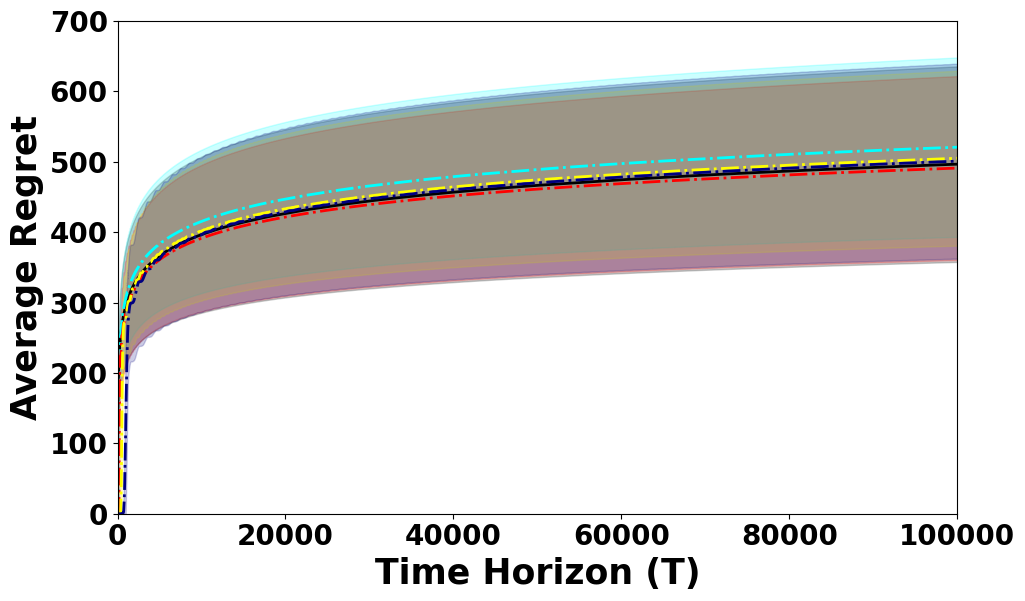

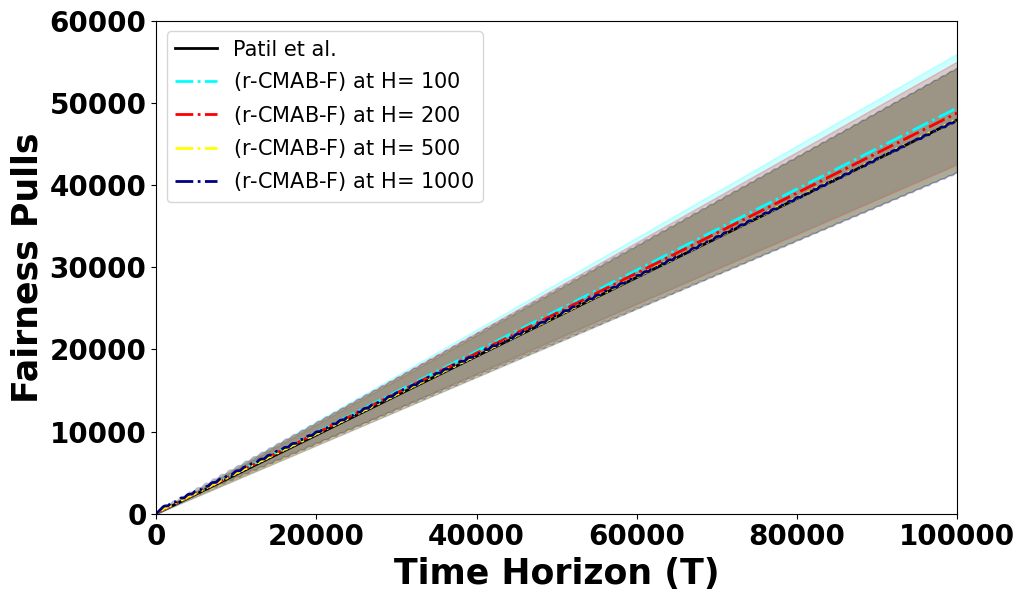

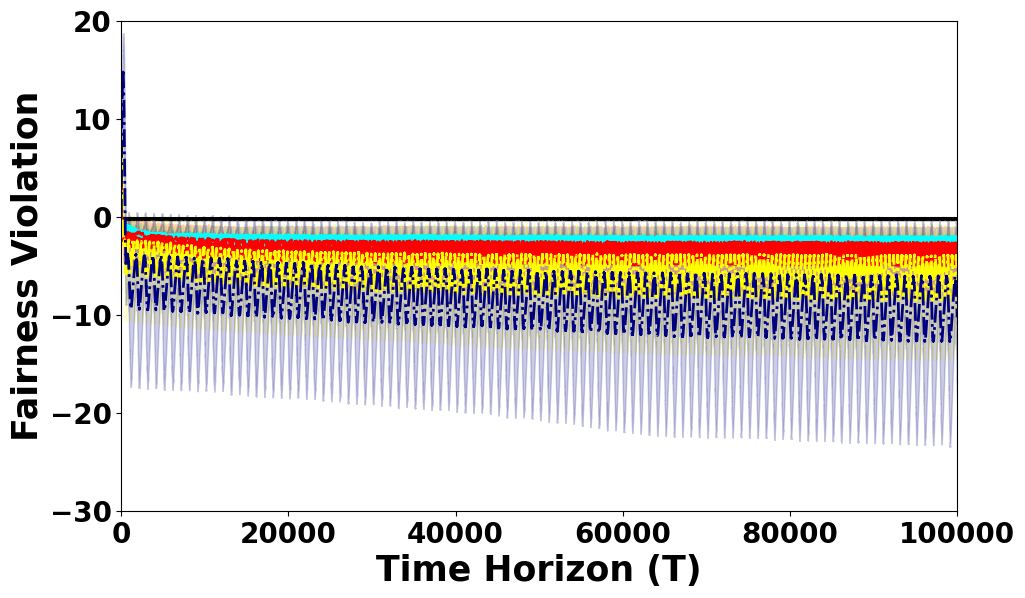

In [ ]:
# import matplotlib.pyplot as plt
# from matplotlib.cm import get_cmap
# import pandas as pd
# import numpy as np

# cmap = get_cmap('hsv', len([100,200,500,1000]) + 1)  # '+1' to ensure enough colors
# # colors = [cmap(i) for i in range(len([100,200,500,1000]) + 1) if i != 0]  # Skip the first color if it's blue
# # 000080
# colors = ['cyan', 'red','yellow','#000080'  ]
# plt.figure(figsize=(10, 6))
# # plt.plot(time, mean_df1.to_numpy(), label='Patil et.al.', color='green')
# mean_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data4.csv',header=None).values.flatten()
# std_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data5.csv',header=None).values.flatten()

# x_values = range(len(mean_values))



# i=0
# # Plot the mean line
# plt.plot(x_values, mean_values, color='black', label='Patil et al.', linewidth=2, linestyle='-')
# plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='black', alpha=0.2)

# for H in [100,200,500,1000]:
#   a=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean4_{H}.csv',header=None).values.flatten()
#   b=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/std4_{H}.csv',header=None).values.flatten()
#   plt.plot(np.arange(0, 100000), a, label=rf'(r-CMAB-F) at H= ${H}$', color=colors[i],linewidth=2, linestyle='-.')
#   # plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)
#   plt.fill_between(np.arange(0, 100000), a-b, a+b, color=colors[i], alpha=0.2)

#   i+=1

# plt.xlabel('Time Horizon (T)',fontsize=25, fontweight='bold')
# plt.ylabel('Average Regret',fontsize=25, fontweight='bold')
# # plt.title('Cumulative Regret vs Time',fontsize=25, fontweight='bold')
# plt.xticks(fontsize=20, fontweight='bold')
# plt.yticks(fontsize=20, fontweight='bold')
# # plt.legend(fontsize=15,loc='upper left')
# plt.tight_layout()
# plt.xlim(0, 100000)  # Limit x-axis to the first 50,000 data points
# plt.ylim(0, 700)
# plt.show()



# mean_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data6.csv',header=None).values.flatten()
# std_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data7.csv',header=None).values.flatten()

# i=0
# plt.figure(figsize=(10, 6))
# plt.plot(x_values, mean_values, color='black', label='Patil et al.', linewidth=2, linestyle='-')
# plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='black', alpha=0.2)
# for H in [100,200,500,1000]:
#   a=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean5_{H}.csv',header=None).values.flatten()
#   b=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/std5_{H}.csv',header=None).values.flatten()

#   plt.plot(np.arange(0, 100000), a, label=rf'(r-CMAB-F) at H= ${H}$', color=colors[i],linewidth=2, linestyle='-.')
#    # plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)
#   plt.fill_between(np.arange(0, 100000), a-b , a+b, color=colors[i], alpha=0.2)

#   i+=1

# # plt.plot(time, mean_df2.to_numpy(), label='Patil et.al.', color='green')
# plt.xlabel('Time Horizon (T)',fontsize=25, fontweight='bold')
# plt.ylabel('Fairness Pulls',fontsize=25, fontweight='bold')
# # plt.title('Fairness pulls vs Time ',fontsize=25, fontweight='bold')
# plt.xticks(fontsize=20, fontweight='bold')
# plt.yticks(fontsize=20, fontweight='bold')
# plt.legend(fontsize=15,loc='upper left')
# plt.tight_layout()
# plt.xlim(0, 100000)  # Limit x-axis to the first 50,000 data points
# plt.ylim(0, 60000)
# plt.show()


# mean_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data8.csv',header=None).values.flatten()
# std_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data9.csv',header=None).values.flatten()
# i=0
# plt.figure(figsize=(10, 6))
# plt.plot(x_values, mean_values, color='black', label='Patil et al.', linewidth=2, linestyle='-')
# plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='black', alpha=0.2)

# for H in [100,200,500,1000]:
#   a=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean6_{H}.csv',header=None).values.flatten()
#   b=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/st6_{H}.csv',header=None).values.flatten()
#   plt.plot(np.arange(0,100000), a, label=rf'(r-CMAB-F) at H= ${H}$', color=colors[i], linewidth=2, linestyle='-.')
#   # plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)
#   plt.fill_between(np.arange(0,100000), a-b , a+b, color=colors[i], alpha=0.2)

#   i+=1
# # plt.plot(time, mean_df3.to_numpy(), label='Patil et.al.', color='green')
# plt.xlabel('Time Horizon (T)',fontsize=25, fontweight='bold')
# plt.ylabel('Fairness Violation',fontsize=25, fontweight='bold')
# # plt.title('Fairness Violation vs Time',fontsize=25, fontweight='bold')
# plt.xticks(fontsize=20, fontweight='bold')
# plt.yticks(fontsize=20, fontweight='bold')
# # plt.legend(fontsize=15,loc='upper right')
# plt.tight_layout()
# plt.xlim(0, 100000)  # Limit x-axis to the first 50,000 data points
# plt.ylim(-30, 20)
# plt.show()


<ipython-input-2-e6dac2eff0ee>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('hsv', len([100,200,500,1000]) + 1)  # '+1' to ensure enough colors


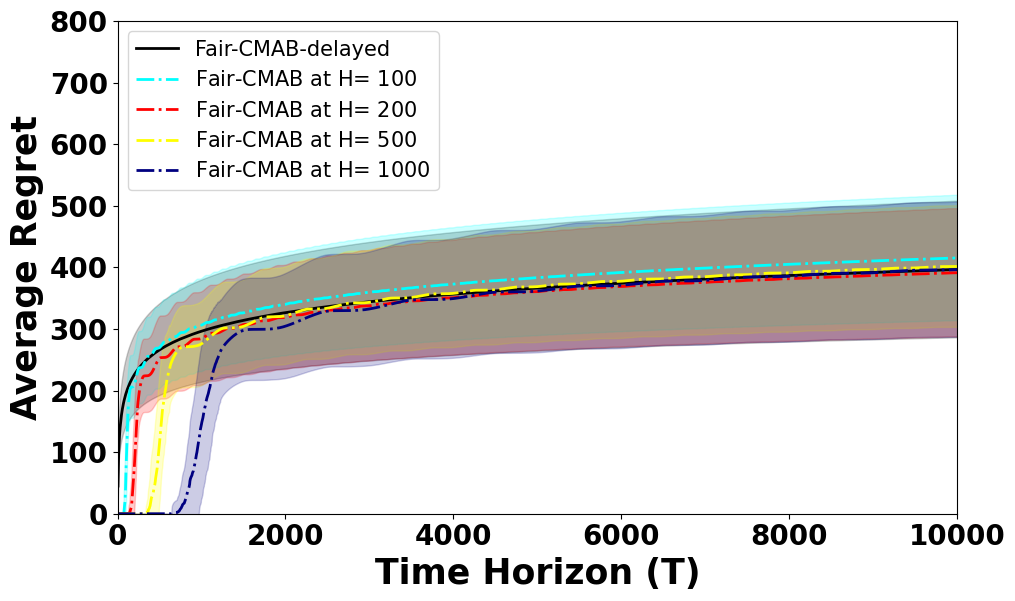

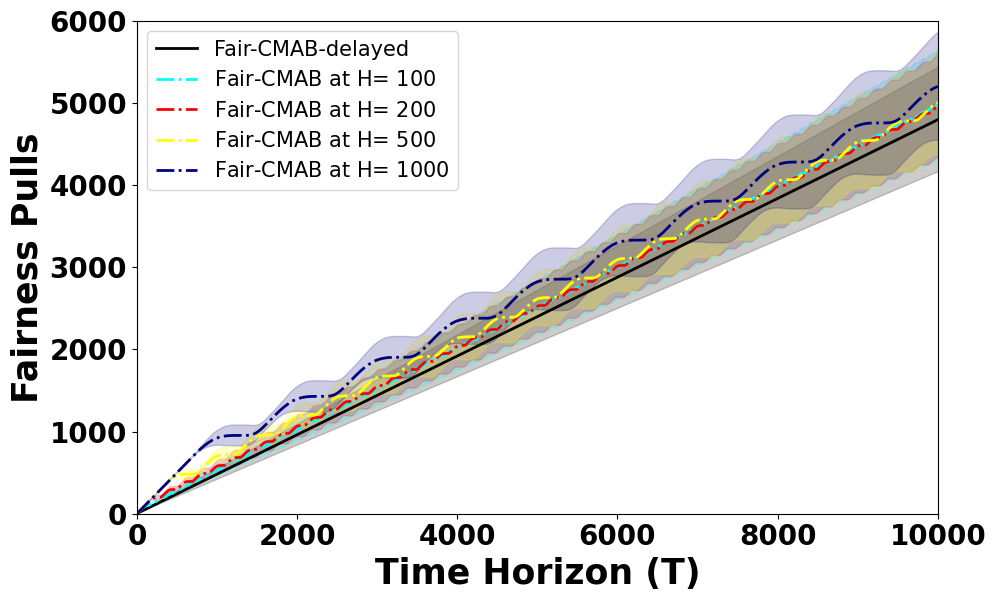

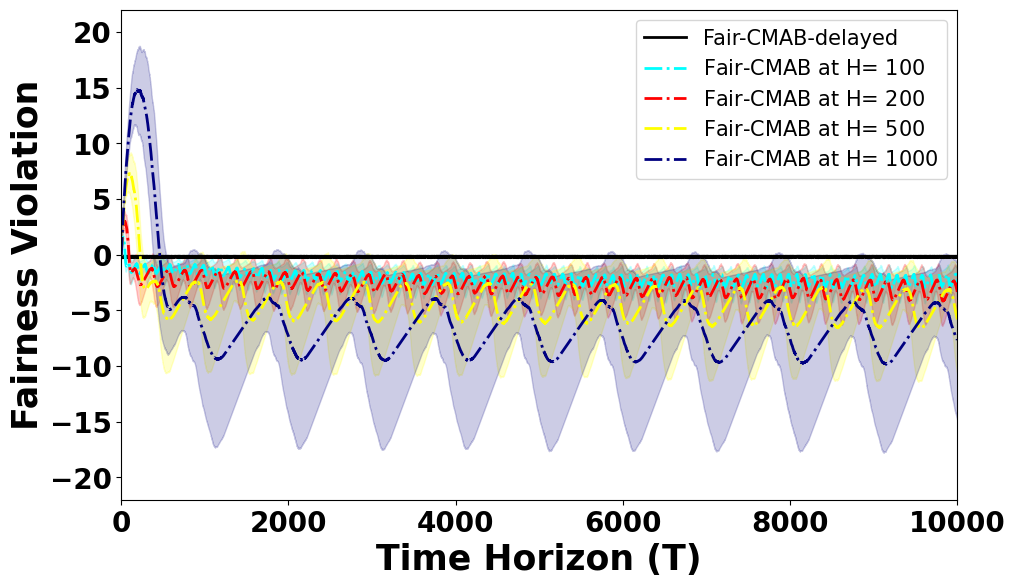

In [2]:


import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import pandas as pd
import numpy as np

cmap = get_cmap('hsv', len([100,200,500,1000]) + 1)  # '+1' to ensure enough colors
# colors = [cmap(i) for i in range(len([100,200,500,1000]) + 1) if i != 0]  # Skip the first color if it's blue
# 000080
colors = ['cyan', 'red','yellow','#000080'  ]
plt.figure(figsize=(10, 6))
# plt.plot(time, mean_df1.to_numpy(), label='Patil et.al.', color='green')
mean_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data4.csv',header=None).values.flatten()
std_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data5.csv',header=None).values.flatten()

x_values = range(len(mean_values))



i=0
# Plot the mean line
plt.plot(x_values, mean_values, color='black', label='Fair-CMAB-delayed', linewidth=2, linestyle='-')
plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='black', alpha=0.2)

for H in [100,200,500,1000]:
  a=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean4_{H}.csv',header=None).values.flatten()
  b=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/std4_{H}.csv',header=None).values.flatten()
  plt.plot(np.arange(0, 100000), a, label=rf'Fair-CMAB at H= ${H}$', color=colors[i],linewidth=2, linestyle='-.')
  # plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)
  plt.fill_between(np.arange(0, 100000), a-b, a+b, color=colors[i], alpha=0.2)

  i+=1

plt.xlabel('Time Horizon (T)',fontsize=25, fontweight='bold')
plt.ylabel('Average Regret',fontsize=25, fontweight='bold')
# plt.title('Cumulative Regret vs Time',fontsize=25, fontweight='bold')
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=20, fontweight='bold')
plt.legend(fontsize=15, loc='upper left')
plt.tight_layout()
plt.xlim(0, 10000)  # Limit x-axis to the first 50,000 data points
plt.ylim(0, 800)
plt.show()



mean_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data6.csv',header=None).values.flatten()
std_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data7.csv',header=None).values.flatten()

i=0
plt.figure(figsize=(10, 6))
plt.plot(x_values, mean_values, color='black', label='Fair-CMAB-delayed', linewidth=2, linestyle='-')
plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='black', alpha=0.2)
for H in [100,200,500,1000]:
  a=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean5_{H}.csv',header=None).values.flatten()
  b=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/std5_{H}.csv',header=None).values.flatten()

  plt.plot(np.arange(0, 100000), a, label=rf'Fair-CMAB at H= ${H}$', color=colors[i],linewidth=2, linestyle='-.')
   # plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)
  plt.fill_between(np.arange(0, 100000), a-b , a+b, color=colors[i], alpha=0.2)

  i+=1

# plt.plot(time, mean_df2.to_numpy(), label='Patil et.al.', color='green')
plt.xlabel('Time Horizon (T)',fontsize=25, fontweight='bold')
plt.ylabel('Fairness Pulls',fontsize=25, fontweight='bold')
# plt.title('Fairness pulls vs Time ',fontsize=25, fontweight='bold')
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=20, fontweight='bold')
plt.legend(fontsize=15, loc='upper left')
plt.tight_layout()
plt.xlim(0, 10000)  # Limit x-axis to the first 50,000 data points
plt.ylim(0, 6000)
plt.show()


mean_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data8.csv',header=None).values.flatten()
std_values=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_5/data9.csv',header=None).values.flatten()
i=0
plt.figure(figsize=(10, 6))
plt.plot(x_values, mean_values, color='black', label='Fair-CMAB-delayed', linewidth=2, linestyle='-')
plt.fill_between(x_values, mean_values - std_values, mean_values + std_values, color='black', alpha=0.2)

for H in [100,200,500,1000]:
  a=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/mean6_{H}.csv',header=None).values.flatten()
  b=pd.read_csv(f'/content/drive/MyDrive/AAMAS2025_6/st6_{H}.csv',header=None).values.flatten()
  plt.plot(np.arange(0,100000), a, label=rf'Fair-CMAB at H= ${H}$', color=colors[i], linewidth=2, linestyle='-.')
  # plt.plot(x_values, mean_values, color='green', label='Patil et.al.', linewidth=2)
  plt.fill_between(np.arange(0,100000), a-b , a+b, color=colors[i], alpha=0.2)

  i+=1
# plt.plot(time, mean_df3.to_numpy(), label='Patil et.al.', color='green')
plt.xlabel('Time Horizon (T)',fontsize=25, fontweight='bold')
plt.ylabel('Fairness Violation',fontsize=25, fontweight='bold')
# plt.title('Fairness Violation vs Time',fontsize=25, fontweight='bold')
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=20, fontweight='bold')
plt.legend(fontsize=15,loc='upper right')
plt.tight_layout()
plt.xlim(0, 10000)  # Limit x-axis to the first 50,000 data points
plt.ylim(-22, 22)
plt.show()
